(sec:clustering)=

# Clustering

Clustering is an unsupervised learning task in which we try to identify structure in data without using labels. Given a dataset $\mathcal{D} = \{\vec{x}_i\}_{i=1}^N$, the goal is to group the data points into $K$ clusters such that points within the same cluster are similar, while points in different clusters are dissimilar.

## Theoretical Foundations

Formally, a clustering algorithm needs two ingredients: an **assignment rule** that assigns each data point $\vec{x}_i$ to one of the clusters $k \in \{1, \ldots, K\}$, and a **reconstruction rule** that represents each cluster by a characteristic point $\vec{m}_k \in \mathbb{R}^d$.

### $k$-Means Clustering

In $k$-means clustering, this representative point is the mean of all data points assigned to the cluster, also called cluster **centroid**. To formulate the method, we denote the clusters by $C_1, \ldots, C_K$, where each $C_k \subseteq \mathcal{D}$ contains the data points assigned to cluster $k$. The corresponding centroids are defined as $\vec{m}_1, \ldots, \vec{m}_K$.

:::{note} Cluster assignments
The clusters must form a partition of the dataset. This means that every data point is assigned to exactly one cluster:

$$
\bigcup_{k=1}^K C_k = \mathcal{D}, \qquad C_i \cap C_j = \emptyset \quad \text{for } i \neq j.
$$
:::

The $k$-means algorithm searches for clusters whose centroids are close to the data points assigned to them, by alternating between two simple update steps. 

If the current assignments are known, the best centroid for cluster $k$ is the mean of the data points in that cluster:

$$
\vec{m}_k \leftarrow \frac{1}{|C_k|} \sum_{\vec{x}_i \in C_k} \vec{x}_i,
$$

where $|C_k|$ is the number of points in cluster $k$. This is the reconstruction step.

If the centroids are known, each data point is assigned to the closest centroid:

$$
C_k \leftarrow \left\{\vec{x}_i \in \mathcal{D} \mid \|\vec{x}_i - \vec{m}_k\|_2 \leq \|\vec{x}_i - \vec{m}_j\|_2 \text{ for all } j \neq k \right\}.
$$

This is the assignment step. Starting from an initial choice of centroids or assignments, the algorithm repeats these two steps until the assignments no longer change or a fixed number of iterations has been reached.

:::{tip} Voronoi cells
:class: dropdown

For fixed centroids, the assignment step divides the feature space into regions called [**Voronoi cells**](https://en.wikipedia.org/wiki/Voronoi_diagram). The Voronoi cell of centroid $\vec{m}_k$ contains all points in feature space that are at least as close to $\vec{m}_k$ as to any other centroid.

:::

## Implementation

We will implement $k$-means as a simple Python class. As before, the short code cells below introduce the class piece by piece, while the complete executable implementation is shown afterwards.

We start with the constructor. The parameter `n_clusters` stores the number of clusters $K$, while `num_iter` controls how many times the assignment and reconstruction steps are repeated. The attributes `centroids` and `labels` are initialised as `None` and will be filled during fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
from IPython.display import HTML, display
from matplotlib.colors import to_hex

np.random.seed(0)

In [2]:
class KMeans:
    def __init__(self, n_clusters=3, num_iter=50):
        self.n_clusters = n_clusters
        self.num_iter = num_iter
        self.centroids = None # (n_clusters, n_features)
        self.labels = None # (n_points)

The `fit` method performs the actual $k$-means algorithm. We first choose `n_clusters` data points at random as the initial centroids using [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html). The argument `replace=False` ensures that the same data point is not selected twice. We then alternate between assigning each point to its closest centroid and recomputing the centroids from the current assignments.

In [3]:
    def fit(self, X):
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.num_iter):
            self.labels = self.assign_labels(X)
            self.centroids = self.compute_centroids(X)

        return self

The `assign_labels` method implements the assignment step. For every data point, we compute the Euclidean distance to every centroid and then use `np.argmin` to select the closest centroid. Here, the expression `X[:, None, :]` adds an extra axis such that the resulting shape is `(n_points, 1, n_features)`. NumPy then broadcasts `self.centroids` as `(1, n_clusters, n_features)`, so the subtraction computes every point-to-centroid difference vector.

In [4]:
    def assign_labels(self, X):
        distances = np.linalg.norm(X[:, None, :] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

The `compute_centroids` method implements the reconstruction step. For each cluster, we select the points currently assigned to that cluster and compute their mean. We achieve this in a single line of code by applying `np.mean` along the first axis (the data points) to all points assigned to each cluster, and collecting the results using a [list comprehension](https://www.geeksforgeeks.org/python/python-list-comprehension/). This results in an array of shape `(n_clusters, n_features)`. The `predict` method then reuses `assign_labels` to assign new data points to the nearest fitted centroid.

In [5]:
    def compute_centroids(self, X):
        return np.array([
            np.mean(X[self.labels == i], axis=0)
            for i in range(self.n_clusters)
        ])

    def predict(self, X):
        return self.assign_labels(X)

:::{tip} Full implementation
:class: dropdown

The complete `KMeans` class is shown below, including explanatory docstrings.

```python
class KMeans:
    """A simple k-means clustering model.

    The model alternates between assigning each point to the nearest centroid
    and recomputing each centroid as the mean of the assigned points.

    Parameters
    ----------
    n_clusters : int
        Number of clusters to identify.
    num_iter : int
        Number of assignment-update iterations.

    Attributes
    ----------
    n_clusters : int
        Number of clusters stored on the model.
    num_iter : int
        Number of iterations stored on the model.
    centroids : 2d-array or None
        Current centroid positions, one row per cluster.
    labels : 1d-array or None
        Current cluster label for each data point.
    """

    def __init__(self, n_clusters=3, num_iter=50):
        """Initialise the model hyperparameters and placeholder attributes."""
        self.n_clusters = n_clusters
        self.num_iter = num_iter
        self.centroids = None
        self.labels = None

    def fit(self, X):
        """Fit the centroids using the k-means update steps."""
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.num_iter):
            self.labels = self.assign_labels(X)
            self.centroids = self.compute_centroids(X)

        return self

    def assign_labels(self, X):
        """Assign each data point to the nearest centroid."""
        distances = np.linalg.norm(X[:, None, :] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def compute_centroids(self, X):
        """Compute centroids as the mean of all points assigned to each cluster."""
        return np.array([
            np.mean(X[self.labels == i], axis=0)
            for i in range(self.n_clusters)
        ])

    def predict(self, X):
        """Assign new data points to the nearest fitted centroid."""
        return self.assign_labels(X)
```

:::

In [6]:
class KMeans:
    def __init__(self, n_clusters=3, num_iter=50):
        self.n_clusters = n_clusters
        self.num_iter = num_iter
        self.centroids = None
        self.labels = None
        self.centroids_history = []
        self.labels_history = []
        self.iteration_history = []
        self.step_history = []

    def store_history(self, iteration, step):
        self.centroids_history.append(self.centroids.copy())
        self.labels_history.append(self.labels.copy())
        self.iteration_history.append(iteration)
        self.step_history.append(step)

    def fit(self, X):
        self.centroids_history = []
        self.labels_history = []
        self.iteration_history = []
        self.step_history = []

        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for iteration in range(1, self.num_iter + 1):
            self.labels = self.assign_labels(X)
            self.store_history(iteration, "Assignment")

            self.centroids = self.compute_centroids(X)
            self.store_history(iteration, "Reconstruction")

        return self

    def assign_labels(self, X):
        distances = np.linalg.norm(X[:, None, :] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def compute_centroids(self, X):
        return np.array([
            np.mean(X[self.labels == i], axis=0)
            for i in range(self.n_clusters)
        ])

    def predict(self, X):
        return self.assign_labels(X)

## Application

We now apply our $k$-means implementation to the conformer dataset from the dimensionality reduction chapter. There, the original molecular descriptors were projected onto the first two principal components, which gives us a two-dimensional representation that can be inspected visually. The projected data are stored in {download}`/assets/data/data_driven_modelling/conformers_pca.csv`.

First, we load the data and extract the two principal-component coordinates.

In [7]:
df = pd.read_csv("conformers_pca.csv")
X = df[["PC1", "PC2"]].to_numpy()
df.head()

,PC1,PC2
0,507.442261,-194.500078
1,490.894175,-188.850747
2,492.580590,-189.064481
3,-248.074962,-134.286191
4,-330.519524,-121.354867


The points already lie in a two-dimensional feature space, so no additional preprocessing is needed for visualisation. We choose a small number of clusters $K$, fit the `KMeans` model, and store the resulting cluster assignments.

:::{tip} On the choice of $K$

Note that the number of clusters is a hyperparameter of the model, which is fixed from the start. In practice, the algorithm is often run for different values of $K$ and the results are compared using an evaluation metric, such as the [silhouette score](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) or the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)).

:::

In [8]:
kmeans = KMeans(n_clusters=3, num_iter=10)
kmeans.fit(X)
cluster_labels = kmeans.predict(X)

Finally, we visualise the clustering result. The data points are coloured by their cluster assignment, annotated with their conformer index, and the learned centroids are shown as black crosses.

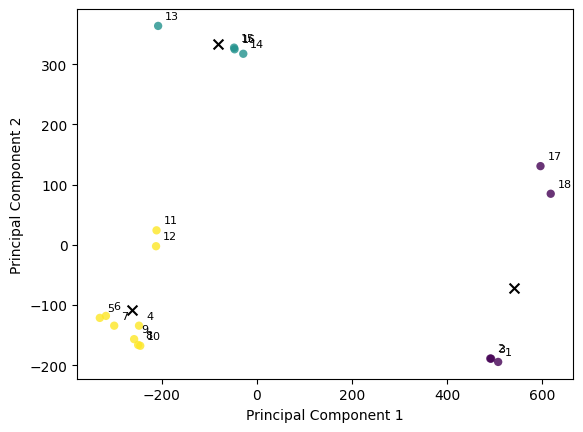

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, alpha=0.8, edgecolor="none")
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c="black", marker="x", s=50)
for i, (x, y) in enumerate(zip(X[:, 0], X[:, 1])):
    plt.annotate(str(i+1), (x, y), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

To better understand how the clusters are found, we can visualise the optimisation process itself. The slider below moves through the history stored on the fitted `kmeans` object. Each iteration has two states: one after the assignment step, where points are recoloured based on the current centroids, and one after the reconstruction step, where the centroids move to the means of the assigned points.

In [10]:
alt.data_transformers.disable_max_rows()

if len(kmeans.centroids_history) == 0:
    raise ValueError("Fit the KMeans model before creating the interactive plot.")

history_rows = []
centroid_rows = []
for step_idx, (labels, centroids, iteration, step) in enumerate(
    zip(
        kmeans.labels_history,
        kmeans.centroids_history,
        kmeans.iteration_history,
        kmeans.step_history,
    )
):
    title = f"Iteration {iteration}: {step}"
    for point_idx, (x1, x2) in enumerate(X):
        history_rows.append(
            {
                "step_idx": step_idx,
                "PC1": x1,
                "PC2": x2,
                "cluster": str(labels[point_idx]),
                "title": title,
            }
        )
    for cluster_idx, (x1, x2) in enumerate(centroids):
        centroid_rows.append(
            {
                "step_idx": step_idx,
                "PC1": x1,
                "PC2": x2,
                "cluster": str(cluster_idx),
                "title": title,
            }
        )

history_df = pd.DataFrame(history_rows)
centroid_df = pd.DataFrame(centroid_rows)
title_df = history_df[["step_idx", "title"]].drop_duplicates()

selected_step = alt.param(
    name="selected_step",
    value=0,
    bind=alt.binding_range(
        min=0,
        max=len(kmeans.centroids_history) - 1,
        step=1,
        name="Step: ",
    ),
)

slider_style = """
<style>
.vega-embed {
  width: 100%;
  display: flex;
  flex-direction: column;
  align-items: center;
}
.vega-embed .vega-bindings {
  width: min(420px, 100%);
  margin: 0.75rem auto 0;
}
.vega-bind {
  display: flex;
  align-items: center;
  width: 100%;
  font-size: 16px;
  line-height: 1.2;
  white-space: nowrap;
}
.vega-bind input[type="range"] {
  flex: 1 1 auto;
  min-width: 260px;
  margin-left: 0.35rem;
  margin-right: 0.75rem;
}
.vega-bind input[type="number"] {
  width: 3.25rem;
  font-size: 15px;
  line-height: 1.2;
  text-align: center;
}
</style>
"""
display(HTML(slider_style))

x_padding = 0.05 * (history_df["PC1"].max() - history_df["PC1"].min())
y_padding = 0.05 * (history_df["PC2"].max() - history_df["PC2"].min())
x_domain = [history_df["PC1"].min() - x_padding, history_df["PC1"].max() + x_padding]
y_domain = [history_df["PC2"].min() - y_padding, history_df["PC2"].max() + y_padding]
cluster_domain = [str(i) for i in range(kmeans.n_clusters)]
cluster_colors = [
    to_hex(plt.cm.viridis(value))
    for value in np.linspace(0, 1, kmeans.n_clusters)
]

points = (
    alt.Chart(history_df)
    .transform_filter("datum.step_idx == selected_step")
    .mark_circle(size=80, opacity=0.95, strokeWidth=0)
    .encode(
        x=alt.X(
            "PC1:Q",
            title="Principal Component 1",
            scale=alt.Scale(domain=x_domain),
            axis=alt.Axis(labels=False, ticks=True),
        ),
        y=alt.Y(
            "PC2:Q",
            title="Principal Component 2",
            scale=alt.Scale(domain=y_domain),
            axis=alt.Axis(labels=False, ticks=True),
        ),
        color=alt.Color(
            "cluster:N",
            title="Cluster",
            scale=alt.Scale(domain=cluster_domain, range=cluster_colors),
            legend=alt.Legend(
                orient="none",
                legendX=450,
                legendY=70,
                fillColor="white",
                padding=6,
            ),
        ),
    )
)

centroids = (
    alt.Chart(centroid_df)
    .transform_filter("datum.step_idx == selected_step")
    .mark_text(text="x", size=24, color="black", fontWeight="normal")
    .encode(
        x=alt.X("PC1:Q"),
        y=alt.Y("PC2:Q"),
    )
)

title = (
    alt.Chart(title_df)
    .transform_filter("datum.step_idx == selected_step")
    .mark_text(align="left", baseline="top", fontSize=20, fontWeight="bold")
    .encode(
        x=alt.value(0),
        y=alt.value(0),
        text="title:N",
    )
    .properties(width=520, height=30)
)

interactive_kmeans_plot = (
    (points + centroids)
    .properties(width=520, height=420)
    .add_params(selected_step)
)

(title & interactive_kmeans_plot).configure_view(stroke=None)

alt.VConcatChart(...)